In [147]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
from lib_equations import bisec, Newt_Rap, Secant_mth

# import lib_plot

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## **Secant Method**

N iter = 100


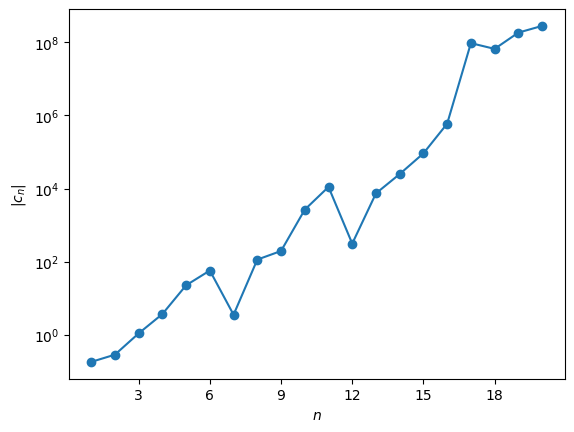

In [148]:
f = lambda x: np.tan(np.pi*x) - 6.0

c, sec_iter, sols = Secant_mth(f, x0 = 0, x1 = 0.48)
print('N iter =', sec_iter)
n_max = 20
plt.plot(np.arange(1, n_max+1), abs(sols)[:n_max], marker='o')
plt.xlabel(r'$n$')
plt.ylabel(r'$|c_n|$')
plt.yscale('log')
from matplotlib.ticker import MaxNLocator

ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()


## **Bound States in a Finite Square Well**

<lambdifygenerated-75>:2: RuntimeWarning: invalid value encountered in divide
  return (1/2)*tan((1/2)*sqrt(2*E + 20))**2 + 1/2 + tan((1/2)*sqrt(2*E + 20))/sqrt(2*E + 20) - 1/2*sqrt(2)*sqrt(-E)/E


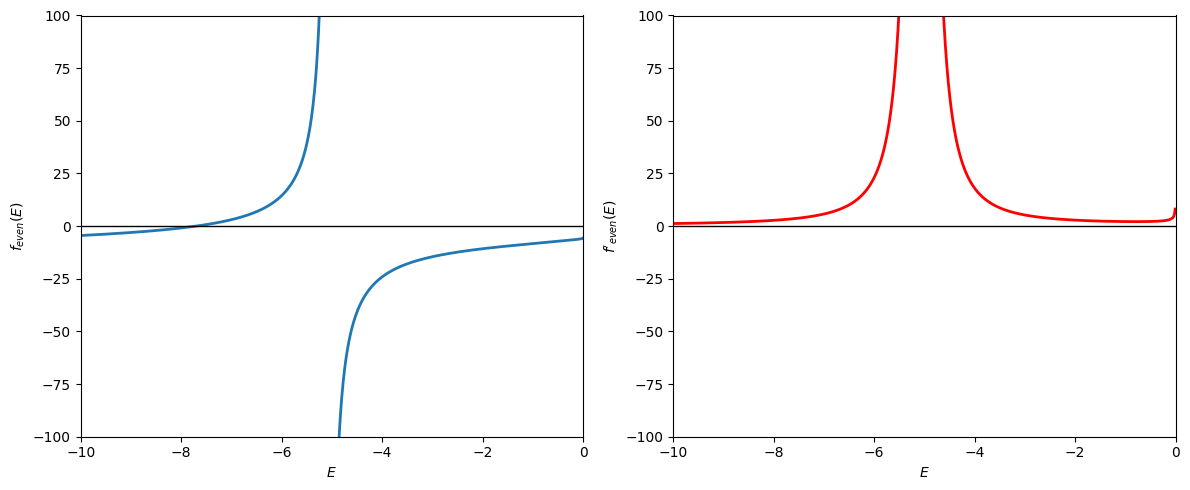

In [149]:
import sympy as sp
# ---- Parameters setup ----
V0 = 10
hbar = m = L = 1

E = sp.symbols('E', real=True)
k = sp.sqrt(2*(V0 + E))
kappa = sp.sqrt(-2*E)

sp_f_even = k*sp.tan(k/2) - kappa
sp_f_odd = k/sp.tan(k/2) + kappa
sp_df_even = sp.diff(sp_f_even, E)
sp_df_odd = sp.diff(sp_f_odd, E)

f_even = sp.lambdify(E, sp_f_even, 'numpy')
f_odd = sp.lambdify(E, sp_f_odd, 'numpy')
df_even = sp.lambdify(E, sp_df_even, 'numpy')
df_odd = sp.lambdify(E, sp_df_odd, 'numpy')


# ---- Plot ----
E_coo = np.linspace(-10, 0, 1000)
f_even_E = f_even(E_coo)
df_even_E = df_even(E_coo)

soglia = 1e5
f_even_E_clean = np.where(np.abs(f_even_E) > soglia, np.nan, f_even_E)
df_even_E_clean = np.where(np.abs(df_even_E) > soglia, np.nan, df_even_E)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

ax1.plot(E_coo, f_even_E_clean, lw=2)
ax1.axhline(0, color='black', lw=1)
ax1.set_ylabel(r'$f_{even}(E)$')
ax1.set_xlabel(r'$E$')
ax1.set_ylim(-100, 100)

ax2.plot(E_coo, df_even_E_clean, lw=2, color='red')
ax2.axhline(0, color='black', lw=1)
ax2.set_ylabel(r"$f'_{even}(E)$")
ax2.set_xlabel(r'$E$')
ax2.set_ylim(-100, 100)

plt.xlim(-10, 0)
plt.tight_layout()
plt.show()


Bisection        c = -7.705009250739094
                 iters = 23

Newton-Raphson   c = -7.705009250739082
                 iters = 4

Secant Mth       c = -7.705009250739084
                 iters = 7


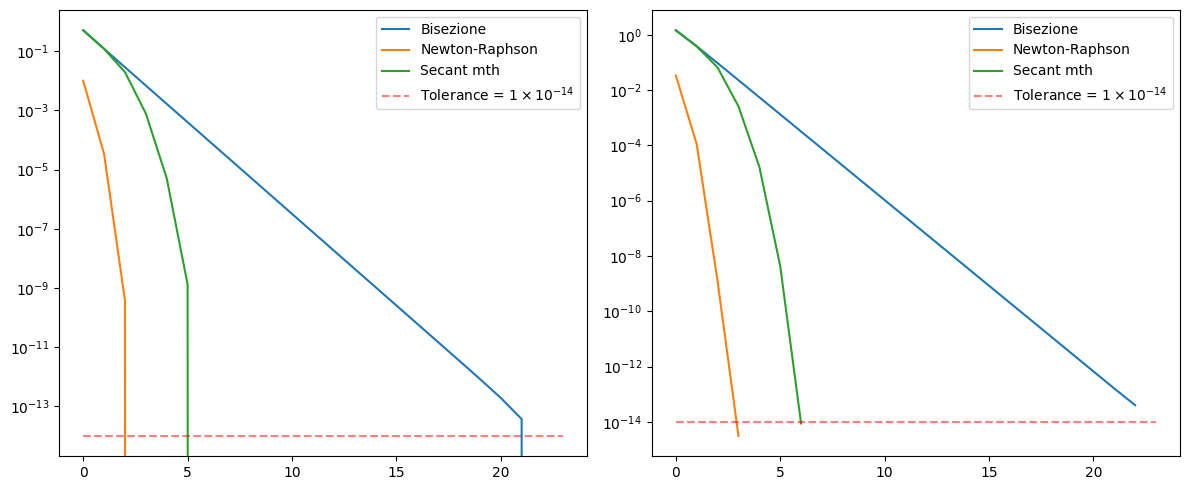

In [150]:
# Root research
c_bis, iter_bis, story_bis = bisec(f_even, -10, -7, out_story=True)
c_NR, iter_NR, story_NR = Newt_Rap(f_even, df_even, -7)
c_Sec, iter_Sec, story_Sec = Secant_mth(f_even, -10, -7)

print('Bisection        c =', c_bis)
print('                 iters =', iter_bis)
print()
print('Newton-Raphson   c =', c_NR)
print('                 iters =', iter_NR)
print()
print('Secant Mth       c =', c_Sec)
print('                 iters =', iter_Sec)

iter_pack = [iter_bis, iter_NR, iter_Sec]
stories = [story_bis, story_NR, story_Sec]
names = ['Bisezione', 'Newton-Raphson', 'Secant mth']
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))
for i in range(3):
    n_iter = iter_pack[i]
    story = stories[i]

    xcoo = np.arange(n_iter)
    errx = abs(story - story[-1])
    erry = abs(np.array([f_even(ele) for ele in story]))
    ax1.plot(xcoo, errx, label=names[i])
    ax2.plot(xcoo, erry, label=names[i])
    
ax1.hlines(1e-14, 0, max(iter_pack), ls='--', color='r', alpha=0.5, label=r'Tolerance = $1\times 10^{-14}$')
ax2.hlines(1e-14, 0, max(iter_pack), ls='--', color='r', alpha=0.5, label=r'Tolerance = $1\times 10^{-14}$')
ax1.set_yscale('log')
ax2.set_yscale('log')
ax1.legend()
ax2.legend()
plt.tight_layout()
plt.show()